<a href="https://colab.research.google.com/github/kb0417/french-ewe-translation-transcription/blob/main/notebooks/01_exploration_dataset_french_ewe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas openpyxl scikit-learn matplotlib seaborn nltk sacrebleu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 4.7 MB/s eta 0:00:00


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from google.colab import files
import pandas as pd
import os

# Upload du fichier Excel
uploaded = files.upload()

# Vérification des fichiers présents
print(os.listdir("/content"))

# Chemin du fichier
file_path = "/content/French_to_ewe_dataset.xlsx"

# Lecture des feuilles
french_df = pd.read_excel(file_path, sheet_name="French")
ewe_df = pd.read_excel(file_path, sheet_name="Ewe")
metadata_df = pd.read_excel(file_path, sheet_name="Metadata")

print("Fichier chargé avec succès !")
print("French :", french_df.shape)
print("Ewe :", ewe_df.shape)
print("Metadata :", metadata_df.shape)

Saving French_to_ewe_dataset.xlsx to French_to_ewe_dataset.xlsx
['.config', 'French_to_ewe_dataset.xlsx', 'sample_data']
Fichier chargé avec succès !
French : (23811, 2)
Ewe : (23811, 2)
Metadata : (23811, 3)


In [6]:
print("Données françaises :")
display(french_df.head())

print("Données éwé :")
display(ewe_df.head())

print("Métadonnées :")
display(metadata_df.head())

Données françaises :


,Unnamed: 0,French
0,0,"Pour raison de santé, j’ai gardé le lit ces de..."
1,1,"désormais, je suis maigre comme un clou de cad..."
2,2,"Voilà alors par compassion, ma belle-mère m’i..."
3,3,Nous sommes le 26 avril
4,4,C'est la veille dun 27 avril


Données éwé :


,Unnamed: 0,Ewe
0,0,metsi anyimlɔƒe ŋkeke eve siawo le dɔlélé ta
1,1,meɖi ku abe zogbeti ene
2,2,esia tae lɔ̃xonye kpem be mava ɖu nu kpli yewo...
3,3,egbee nye tedoxe 26 lia
4,4,edo ʋɔ na tedoxe 27 lia aɖe


Métadonnées :


,Unnamed: 0,Source,Type
0,0,https://aphtalcisse.tg/,Blog
1,1,https://aphtalcisse.tg/,Blog
2,2,https://aphtalcisse.tg/,Blog
3,3,https://aphtalcisse.tg/,Blog
4,4,https://aphtalcisse.tg/,Blog


In [7]:
dataset = pd.DataFrame({
    "french": french_df["French"],
    "ewe": ewe_df["Ewe"],
    "source": metadata_df["Source"],
    "type": metadata_df["Type"]
})

dataset.head()

,french,ewe,source,type
0,"Pour raison de santé, j’ai gardé le lit ces de...",metsi anyimlɔƒe ŋkeke eve siawo le dɔlélé ta,https://aphtalcisse.tg/,Blog
1,"désormais, je suis maigre comme un clou de cad...",meɖi ku abe zogbeti ene,https://aphtalcisse.tg/,Blog
2,"Voilà alors par compassion, ma belle-mère m’i...",esia tae lɔ̃xonye kpem be mava ɖu nu kpli yewo...,https://aphtalcisse.tg/,Blog
3,Nous sommes le 26 avril,egbee nye tedoxe 26 lia,https://aphtalcisse.tg/,Blog
4,C'est la veille dun 27 avril,edo ʋɔ na tedoxe 27 lia aɖe,https://aphtalcisse.tg/,Blog


In [8]:
dataset.shape

(23811, 4)

In [9]:
dataset.isnull().sum()

dataset = dataset.dropna(subset=["french", "ewe"])
dataset = dataset.drop_duplicates(subset=["french", "ewe"])

dataset.shape

(23525, 4)

In [10]:
for i in range(5):
    print("FR :", dataset.iloc[i]["french"])
    print("EWE:", dataset.iloc[i]["ewe"])
    print("-" * 80)

FR : Pour raison de santé, j’ai gardé le lit ces deux derniers jours
EWE: metsi anyimlɔƒe ŋkeke eve siawo le dɔlélé ta
--------------------------------------------------------------------------------
FR : désormais, je suis maigre comme un clou de cadre pour photo
EWE: meɖi ku abe zogbeti ene
--------------------------------------------------------------------------------
FR :  Voilà alors par compassion, ma belle-mère m’invite à partager un dîner avec eux, afin de reprendre quelques forces
EWE: esia tae lɔ̃xonye kpem be mava ɖu nu kpli yewo ale be magakpɔ ŋusẽ
--------------------------------------------------------------------------------
FR : Nous sommes le 26 avril
EWE: egbee nye tedoxe 26 lia
--------------------------------------------------------------------------------
FR : C'est la veille dun 27 avril
EWE: edo ʋɔ na tedoxe 27 lia aɖe
--------------------------------------------------------------------------------


In [11]:
dataset["french_length"] = dataset["french"].apply(lambda x: len(str(x).split()))
dataset["ewe_length"] = dataset["ewe"].apply(lambda x: len(str(x).split()))

dataset[["french_length", "ewe_length"]].describe()

,french_length,ewe_length
count,23525.000000,23525.000000
mean,17.278172,12.213518
std,10.548045,6.486322
min,1.000000,1.000000
25%,10.000000,7.000000
50%,15.000000,11.000000
75%,23.000000,16.000000
max,105.000000,69.000000


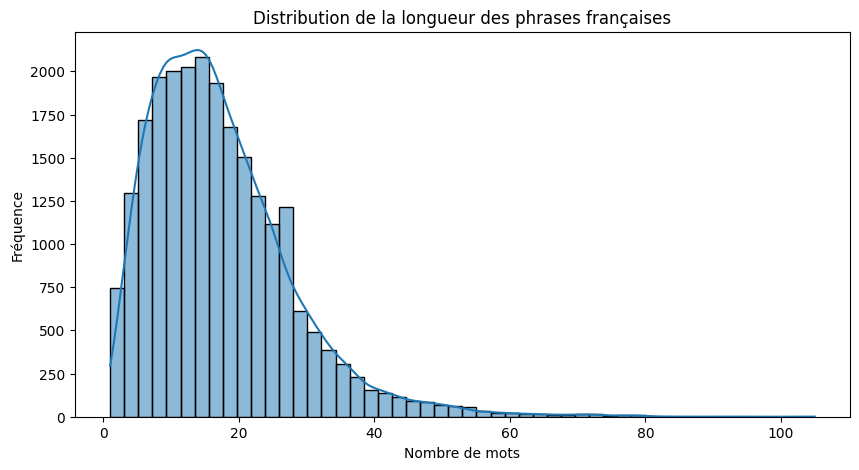

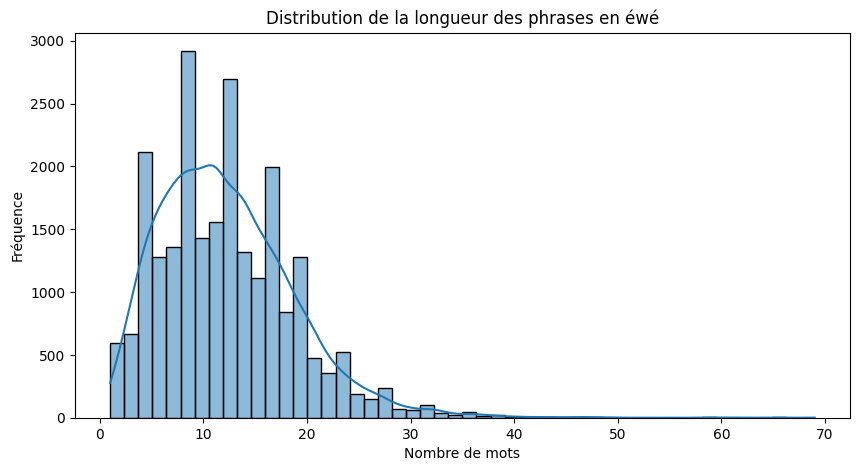

In [13]:
plt.figure(figsize=(10, 5))
sns.histplot(dataset["french_length"], bins=50, kde=True)
plt.title("Distribution de la longueur des phrases françaises")
plt.xlabel("Nombre de mots")
plt.ylabel("Fréquence")
plt.show()


plt.figure(figsize=(10, 5))
sns.histplot(dataset["ewe_length"], bins=50, kde=True)
plt.title("Distribution de la longueur des phrases en éwé")
plt.xlabel("Nombre de mots")
plt.ylabel("Fréquence")
plt.show()

In [14]:
# On divise d'abord le dataset en deux parties :
# - train_df : les données utilisées pour entraîner le modèle
# - temp_df : les données restantes, qui seront ensuite séparées en validation et test
train_df, temp_df = train_test_split(
    dataset,
    test_size=0.2,
    random_state=42
)

# On coupe maintenant temp_df en deux parties égales :
# - valid_df : utilisé pour suivre les performances pendant l'entraînement
# - test_df : utilisé uniquement à la fin pour évaluer le modèle
valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42
)

print("Train :", train_df.shape)
print("Validation :", valid_df.shape)
print("Test :", test_df.shape)

Train : (18820, 6)
Validation : (2352, 6)
Test : (2353, 6)


In [15]:
train_df.to_csv("train.csv", index=False)
valid_df.to_csv("valid.csv", index=False)
test_df.to_csv("test.csv", index=False)

dataset.to_csv("french_ewe_clean.csv", index=False)

In [16]:
# On télécharge les fichiers générés pour pouvoir ensuite les ajouter au repo GitHub.

files.download("french_ewe_clean.csv")
files.download("train.csv")
files.download("valid.csv")
files.download("test.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>